In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("data/SGJobData.csv")

In [3]:
# IMPORTANT: assumed that df_clean contains the following, processed by the team

# df_clean contains:
# - primary_category (parsed)
# - positionLevels
# - minimumYearsExperience
# - outliers already handled
# - filtered dataset (agency/direct based on team decision)

df_clean.head()

,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,...,occupationId,positionLevels,postedCompany_name,salary_maximum,salary_minimum,salary_type,status_id,status_jobStatus,title,average_salary
0,"[{""id"":13,""category"":""Environment / Health""},{...",Permanent,2023-05-08,False,MCF-2023-0252866,2023-04-08,2023-03-30,2,5,151,...,NaN,Executive,WORKSTONE PTE. LTD.,2800,2000,Monthly,0,Closed,Food Technologist - Clementi | Entry Level | U...,2400.0
1,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273977,2023-04-08,2023-04-08,0,0,55,...,NaN,Executive,TRUST RECRUIT PTE. LTD.,5500,4000,Monthly,0,Closed,"Software Engineer (Fab Support) (Java, CIM, Up...",4750.0
2,"[{""id"":33,""category"":""Repair and Maintenance""}]",Full Time,2023-04-22,False,MCF-2023-0273994,2023-04-08,2023-04-08,0,7,99,...,NaN,Senior Executive,PU TIEN SERVICES PTE. LTD.,4600,3800,Monthly,0,Closed,Senior Technician,4200.0
3,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273991,2023-04-08,2023-04-08,0,6,113,...,NaN,Senior Executive,TRUST RECRUIT PTE. LTD.,10000,5000,Monthly,0,Closed,"Senior .NET Developer (.NET Core, MVC, MVVC, S...",7500.0
4,"[{""id"":2,""category"":""Admin / Secretarial""}]",Full Time,2023-05-08,False,MCF-2023-0273976,2023-04-08,2023-04-08,0,3,99,...,NaN,Non-executive,EATZ CATERING SERVICES PTE. LTD.,3400,2400,Monthly,0,Closed,Sales / Admin Cordinator,2900.0


In [7]:
# first we calculate the midpoint_salary (midpoint between minimum and maximum salary)
# this is needed because job postings provides a salary range instead of a single number
# aim is to convert each job into a single comparable value
# make use of the midpoint between minimum and maximum salary to avoid biasing towards the minimum/maximum salary
df_clean["midpoint_salary"] = (
    df_clean["salary_minimum"] + df_clean["salary_maximum"]
) / 2

In [ ]:
# Groups jobs by: Category (e.g. IT, Finance), Position level (e.g., Executive, Manager), Years of experience
# then compute the median salary for each group
# note that median is used instead of mean because high paying outliers can distort averages
# median is a good representation of the typical market salary for each group
# therefore we recommend salary based on the median of comparable roles (same category, level, and experience)
salary_table = df_clean.groupby(
    ["primary_category", "positionLevels", "minimumYearsExperience"]
)["midpoint_salary"].median().reset_index()

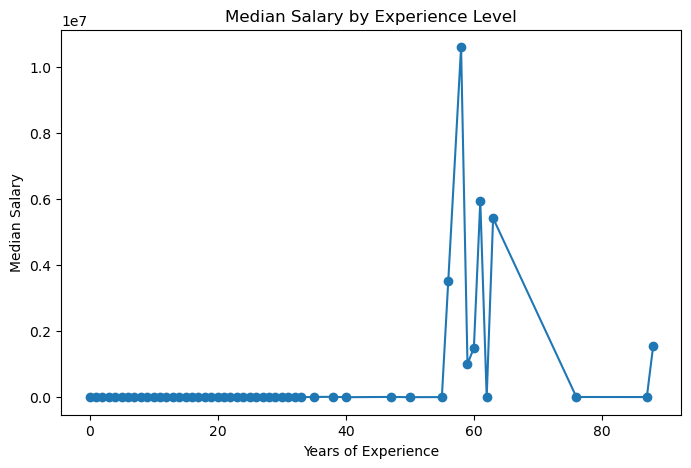

In [ ]:
# visualize the relationship between experience and salary
# we want to show the salary structure of the market
exp_median = df_clean.groupby("minimumYearsExperience")["midpoint_salary"].median()

plt.figure(figsize=(8,5))
plt.plot(exp_median.index, exp_median.values, marker="o")

plt.title("Median Salary by Experience Level")
plt.xlabel("Years of Experience")
plt.ylabel("Median Salary")

plt.show()

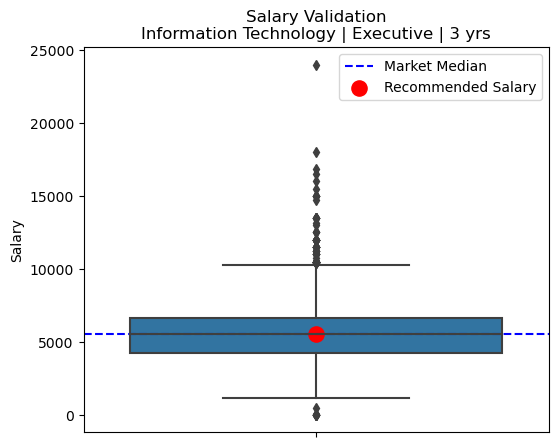

In [ ]:
# validation chart
#given one specific job context
# - the boxplot should show where most market salaries lies
# - what the median is
# - where our recommendation sits
# this chart is use to answer whether the recommended salary is reasonable and competitive in the market

category = "Information Technology"
level = "Executive"
experience = 3

# Selecting only job postings that match a specific role context
subset = df_clean[
    (df_clean["primary_category"] == category) &
    (df_clean["positionLevels"] == level) &
    (df_clean["minimumYearsExperience"] == experience)
]

# Market median (this is your recommended value logic)
recommended_salary = subset["midpoint_salary"].median()

plt.figure(figsize=(6,5))

# Boxplot = market distribution
sns.boxplot(y=subset["midpoint_salary"])

# Add market median line
plt.axhline(
    recommended_salary,
    color="blue",
    linestyle="--",
    label="Market Median"
)

# Add recommended salary point (same here, but explicit)
plt.scatter(
    0,
    recommended_salary,
    color="red",
    s=120,
    label="Recommended Salary"
)

plt.title(f"Salary Validation\n{category} | {level} | {experience} yrs")
plt.ylabel("Salary")
plt.legend()
plt.show()